In [1]:
# Importation de NumPy pour les calculs numériques
import numpy as np

# Importation de Matplotlib pour les graphes
import matplotlib.pyplot as plt


In [2]:
# Sous-ensemble reel de paires de traduction anglais-francais
# Source : corpus Tatoeba (via github.com/L1aoXingyu/seq2seq-translation), filtre et sous-echantillonne
TRANSLATION_PAIRS = [
    ('she is habitually late .', 'elle est habituellement en retard .'),
    ('he is not an american .', "il n'est pas americain ."),
    ('she is her friend .', 'elle est son amie .'),
    ('you are a good cook .', 'tu es bon cuisinier .'),
    ('i am too short .', 'je suis trop petit .'),
    ('they are making a salad .', 'ils font une salade .'),
    ('you are a bad person .', 'vous etes un etre mauvais .'),
    ('i am tired .', 'je suis fatigue !'),
    ('they are not tired .', 'elles ne sont pas fatiguees .'),
    ('he is playing music .', 'il joue de la musique .'),
    ('they are great friends .', 'elles sont de grandes amies .'),
    ('he is a harsh critic .', "c'est un critique acerbe ."),
    ('they are my friends .', 'ce sont mes amis .'),
    ('we are watching .', 'nous regardons .'),
    ('he is very good looking .', 'il est tres seduisant .'),
    ('i am very pleased .', 'je suis tres satisfait .'),
    ('you are blushing .', 'tu rougis !'),
    ('he is absent from school .', "il est absent de l'ecole ."),
    ('we are good friends .', 'nous sommes bons amis .'),
    ('he is unmarried .', "il n'est pas marie ."),
    ('you are fabulous .', 'tu es fabuleux .'),
    ('i am very pleased .', 'je suis tres content .'),
    ('he is only a child .', "il n'est qu'un enfant ."),
    ('he is walking very slowly .', 'il marche tres lentement .'),
    ('i am at home .', 'je suis a la maison .'),
    ('you are not japanese .', "vous n'etes pas japonaise ."),
    ('he is ready to work .', 'il est pret a travailler .'),
    ('they are very kind .', 'ils sont tres bienveillants .'),
    ('you are the chosen one .', "vous etes l'elu ."),
    ('he is all but dead .', 'il est tout sauf mort .'),
    ('he is fluent in english .', 'il parle anglais couramment .'),
    ('he is likely to come .', 'il va probablement venir .'),
    ('he is very careful .', 'il est tres soigneux .'),
    ('you are the chosen one .', "tu es l'elu ."),
    ('it is too hot .', 'il fait trop chaud .'),
    ('he is a spoiled child .', "c'est un enfant gate ."),
    ('he is a daredevil .', "c'est un casse cou ."),
    ('i am on duty now .', 'je suis actuellement en service .'),
    ('he is selfish and greedy .', 'il est egoiste et cupide .'),
    ('you are not japanese .', "tu n'es pas japonaise ."),
    ('she is a gifted artist .', 'elle est une artiste nee .'),
    ('i am fond of music .', "j'adore la musique ."),
    ('she is not here yet .', "elle n'est pas encore la ."),
    ('we are classmates .', 'nous sommes camarades de classe .'),
    ('he is reading .', 'il lit .'),
    ('i am sorry for you .', 'je suis desole pour toi .'),
    ('i am a stranger here .', 'ici je suis un etranger .'),
    ("he isn't an american .", "il n'est pas americain ."),
    ('she is a wonderful wife .', "c'est une femme magnifique ."),
    ('you are big .', 'tu es grande .'),
    ('she is hostile to me .', "elle m'est hostile ."),
    ('they are very kind .', 'elles sont tres gentilles .'),
    ('he is wearing glasses .', 'il porte des lunettes .'),
    ('she is about my age .', 'elle a environ mon age .'),
    ('he is always neatly dressed .', 'il est toujours soigneusement vetu .'),
    ('i am afraid to go .', "j'ai peur de m'y rendre ."),
    ('she is a reliable person .', 'on peut compter sur elle .'),
    ('i am frying fish .', 'je fais frire du poisson .'),
    ('he is seeking employment .', 'il cherche un emploi .'),
    ("he isn't perfect .", "il n'est pas parfait ."),
    ('he is sharp witted .', "il a l'esprit vif ."),
    ('i am not kidding .', 'je ne blague pas .'),
    ('we are teachers .', 'nous sommes enseignants .'),
    ('she is not tall .', "elle n'est pas grande ."),
    ('you are a doctor .', 'vous etes medecin .'),
    ('you are so cute .', 'comme tu es mignonne .'),
    ('she is a wonderful woman .', "c'est une femme magnifique ."),
    ('you are very insensitive .', 'vous etes tres indelicats .'),
    ('it is of great value .', "c'est de grande valeur ."),
    ('he is late .', 'il est en retard .'),
    ('you are a good boy .', "t'es un bon garcon !"),
    ('you are overworked .', 'tu es surmene .'),
    ('she is a good swimmer .', 'elle est bonne nageuse .'),
    ('it is foggy .', 'il y a du brouillard .'),
    ('you are so stupid .', 'tu es tellement idiote !'),
    ('i am rather happy .', 'je suis assez content .'),
    ("it is pochi's food .", "c'est la nourriture de pochi ."),
    ('they are very cheerful .', 'elles sont fort joyeuses .'),
    ('he is incompetent .', 'il est incompetent .'),
    ('he is thirty years old .', 'il a trente ans .'),
    ('you are early .', 'vous etes matinal .'),
    ('i am very tall .', 'je suis tres grande .'),
    ('he is washing his car .', 'il lave sa voiture .'),
    ('you are so stupid .', 'tu es tellement idiot !'),
    ('it is a payday today .', "aujourd'hui c'est jour de paie ."),
    ('he is suspected of robbery .', 'il est suspecte de vol .'),
    ('i am going to sleep .', 'je vais dormir .'),
    ('he is a good carpenter .', 'il est bon charpentier .'),
    ("you aren't my mother .", "vous n'etes pas ma mere ."),
    ('he is boiling with rage .', 'il bout de colere .'),
    ('i m able to speak .', 'je suis capable de parler .'),
    ('she is a doctor .', 'elle est medecin .'),
    ('he is an actor .', "c'est un acteur ."),
    ("we aren't married .", 'nous ne sommes pas maries .'),
    ('he is an office worker .', "c'est un employe de bureau ."),
    ("you aren't looking .", 'vous ne regardez pas .'),
    ("you aren't tom .", "tu n'es pas tom ."),
    ('you are so childish sometimes .', 'tu es parfois si puerile .'),
    ('she is a poor cook .', "c'est une pietre cuisiniere ."),
    ('he is playing there .', 'il y joue .'),
    ('he is busy .', 'il a a faire .'),
    ('you are my daughter .', 'vous etes ma fille .'),
    ('you are the one .', 'tu es celui la .'),
    ('you are a good boy .', 'vous etes un bon garcon .'),
    ('you are big .', 'vous etes grand .'),
    ('you are good .', 'tu es bon .'),
    ('she is curt .', "elle n'a pas de charme ."),
    ('i am okay .', 'je vais bien .'),
    ('you are beautiful .', 'vous etes belles .'),
    ('it is under the chair .', 'il est sous la chaise .'),
    ('he is a big prankster .', "c'est un grand farceur ."),
    ('i am a professor .', 'je suis professeur .'),
    ('i am calm .', 'je suis calme .'),
    ('she is expecting a child .', 'elle attend un enfant .'),
    ('i am tired of homework .', 'je suis fatiguee des devoirs .'),
    ('they are reading her book .', 'elles lisent son livre .'),
    ('i am very tired .', 'je suis tres fatigue .'),
    ('we are teachers .', 'nous sommes enseignantes .'),
    ('it is almost three .', 'il est presque trois heures .'),
    ('i am better .', 'je suis mieux .'),
    ('i am in london .', 'je suis a londres .'),
    ('she is out of danger .', 'elle est hors de danger .'),
    ('you are seriously ill .', 'vous etes un grand malade .'),
    ("you aren't invited .", "vous n'etes pas invitees ."),
    ('he is very brave .', 'il est fort courageux .'),
    ('he is willing enough .', 'il a suffisamment de volonte .'),
    ('he is a born poet .', "c'est un poete ne ."),
    ('i am lazy .', 'je suis faineante .'),
    ('i am terribly hungry .', "j'ai terriblement faim ."),
    ('i am brushing my teeth .', 'je me brosse les dents .'),
    ('he is in pajamas .', 'il est en pyjama .'),
    ('you are a good person .', 'vous etes une chouette gonzesse .'),
    ('he is his own master .', 'il est son propre maitre .'),
    ('it is possible .', "c'est possible ."),
    ('i am exhausted .', 'je suis fourbu .'),
    ('he is always day dreaming .', 'il revasse toujours .'),
    ('he is crazy about skiing .', 'il est fou de ski .'),
    ('you are the one .', 'vous etes celle la .'),
    ('i am almost ready .', 'je suis quasiment prete .'),
    ('you are so stupid .', 'vous etes tellement idiots !'),
    ('they are five in all .', 'ils sont cinq en tout .'),
    ('they are christians .', 'ils sont chretiens .'),
    ('they are jealous of us .', 'ils sont jaloux de nous .'),
    ('i am a stranger here .', 'je suis un etranger ici .'),
    ('they are melons .', 'ce sont des melons .'),
    ('you are tallest .', 'tu es le plus grand .'),
    ('i am a tourist .', 'je suis touriste .'),
    ('they are good people .', 'ce sont de bonnes gens .'),
    ('it is a book .', "c'est un livre ."),
    ('i am looking at that .', 'je regarde ca .'),
]

print(len(TRANSLATION_PAIRS), "paires de traduction anglais -> français (corpus Tatoeba)")


150 paires de traduction anglais -> français (corpus Tatoeba)


In [3]:
# 1. Construction du vocabulaire (mot -> index et index -> mot) pour chaque langue
class Vocab:
    def __init__(self, name):
        self.name = name
        self.word2idx = {"<pad>": 0, "<sos>": 1, "<eos>": 2}
        self.idx2word = {0: "<pad>", 1: "<sos>", 2: "<eos>"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for w in sentence.split():
            if w not in self.word2idx:
                self.word2idx[w] = self.n_words
                self.idx2word[self.n_words] = w
                self.n_words += 1

    def encode(self, sentence, add_eos=True):
        idx = [self.word2idx[w] for w in sentence.split()]
        if add_eos:
            idx.append(self.word2idx["<eos>"])
        return idx

    def decode(self, indices):
        words = [self.idx2word[i] for i in indices if i not in (0, 1, 2)]
        return " ".join(words)

eng_vocab, fra_vocab = Vocab("eng"), Vocab("fra")
for e, f in TRANSLATION_PAIRS:
    eng_vocab.add_sentence(e)
    fra_vocab.add_sentence(f)

V_in, V_out = eng_vocab.n_words, fra_vocab.n_words
print("Vocabulaire anglais :", V_in, "mots | Vocabulaire français :", V_out, "mots")


Vocabulaire anglais : 215 mots | Vocabulaire français : 258 mots


## Mini-moteur de différentiation automatique (from scratch)

Le Transformer combine beaucoup d'opérations (attention, softmax, layer norm, feed-forward...) dont dériver la rétropropagation *à la main, terme à terme* devient très risqué en un temps limité. On construit donc ici un **mini-moteur d'autodiff** (inspiré de *micrograd*), **entièrement en NumPy, sans aucun framework de Deep Learning** : une classe `Tensor` qui enregistre le graphe de calcul et sait rétropropager le gradient automatiquement via la règle de la chaîne, pour chaque opération qu'on lui implémente nous-mêmes (`+`, `*`, `@`, `softmax`, `layernorm`, `relu`...). C'est toujours "from scratch" : c'est nous qui codons *comment* chaque opération se dérive — on évite juste de le refaire à la main pour chaque combinaison self-attention + cross-attention + FFN + layer norm.

In [4]:
# 2. Mini-moteur d'autodiff (reverse-mode), 100% NumPy
class Tensor:
    def __init__(self, data, children=(), op=""):
        self.data = np.array(data, dtype=np.float64)
        self.grad = np.zeros_like(self.data)
        self._backward = lambda: None
        self._prev = children
        self.op = op

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += _unbroadcast(out.grad * other.data, self.data.shape)
            other.grad += _unbroadcast(out.grad * self.data, other.data.shape)
        out._backward = _backward
        return out

    def __matmul__(self, other):
        out = Tensor(self.data @ other.data, (self, other), "@")
        def _backward():
            self.grad += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1.0

    def __sub__(self, other):
        return self + (-(other if isinstance(other, Tensor) else Tensor(other)))

    def T(self):
        out = Tensor(self.data.T, (self,), "T")
        def _backward():
            self.grad += out.grad.T
        out._backward = _backward
        return out

    def sum(self):
        out = Tensor(self.data.sum(), (self,), "sum")
        def _backward():
            self.grad += np.ones_like(self.data) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Tensor(np.maximum(0, self.data), (self,), "relu")
        def _backward():
            self.grad += (self.data > 0) * out.grad
        out._backward = _backward
        return out

    # Self-attention / cross-attention : softmax appliqué ligne par ligne
    def softmax(self, axis=-1):
        z = self.data - np.max(self.data, axis=axis, keepdims=True)
        e = np.exp(z)
        s = e / np.sum(e, axis=axis, keepdims=True)
        out = Tensor(s, (self,), "softmax")
        def _backward():
            g = out.grad
            dot = np.sum(g * s, axis=axis, keepdims=True)
            self.grad += s * (g - dot)
        out._backward = _backward
        return out

    # Layer Normalization (utilisée après chaque sous-couche du Transformer)
    def layernorm(self, gamma, beta, eps=1e-5):
        mu = self.data.mean(axis=-1, keepdims=True)
        var = self.data.var(axis=-1, keepdims=True)
        xhat = (self.data - mu) / np.sqrt(var + eps)
        out_data = xhat * gamma.data + beta.data
        out = Tensor(out_data, (self, gamma, beta), "ln")
        N = self.data.shape[-1]
        def _backward():
            dxhat = out.grad * gamma.data
            std_inv = 1.0 / np.sqrt(var + eps)
            dvar = np.sum(dxhat * (self.data - mu) * -0.5 * std_inv**3, axis=-1, keepdims=True)
            dmu = np.sum(dxhat * -std_inv, axis=-1, keepdims=True) + dvar * np.mean(-2*(self.data-mu), axis=-1, keepdims=True)
            self.grad += dxhat*std_inv + dvar*2*(self.data-mu)/N + dmu/N
            gamma.grad += np.sum(out.grad * xhat, axis=tuple(range(out.grad.ndim-1)))
            beta.grad += np.sum(out.grad, axis=tuple(range(out.grad.ndim-1)))
        out._backward = _backward
        return out

    def backward(self):
        topo, visited = [], set()
        def build(v):
            if id(v) not in visited:
                visited.add(id(v))
                for c in v._prev:
                    build(c)
                topo.append(v)
        build(self)
        self.grad = np.ones_like(self.data)
        for v in reversed(topo):
            v._backward()

def _unbroadcast(grad, shape):
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for i, s in enumerate(shape):
        if s == 1 and grad.shape[i] != 1:
            grad = grad.sum(axis=i, keepdims=True)
    return grad

def concat_cols(tensors):
    """Concatène des Tensors (T, d_head) le long de l'axe des colonnes -> (T, d_model)."""
    data = np.concatenate([t.data for t in tensors], axis=1)
    out = Tensor(data, tuple(tensors), "concat_cols")
    def _backward():
        c = 0
        for t in tensors:
            n = t.data.shape[1]
            t.grad += out.grad[:, c:c+n]
            c += n
    out._backward = _backward
    return out

def cross_entropy(logits, targets):
    """Softmax + Negative Log-Likelihood combinés (stables numériquement)."""
    z = logits.data - np.max(logits.data, axis=-1, keepdims=True)
    e = np.exp(z)
    probs = e / np.sum(e, axis=-1, keepdims=True)
    T = logits.data.shape[0]
    nll = -np.mean(np.log(probs[np.arange(T), targets] + 1e-9))
    out = Tensor(nll, (logits,), "cross_entropy")
    def _backward():
        g = probs.copy()
        g[np.arange(T), targets] -= 1
        g /= T
        logits.grad += g * out.grad
    out._backward = _backward
    return out

def embed_lookup(E, idx_list):
    data = E.data[idx_list]
    out = Tensor(data, (E,), "embed")
    def _backward():
        for i, idx in enumerate(idx_list):
            E.grad[idx] += out.grad[i]
    out._backward = _backward
    return out

def positional_encoding(T, d):
    """Encodage positionnel sinusoïdal (le Transformer n'a pas de récurrence,
    il faut donc injecter explicitement l'ordre des mots)."""
    pe = np.zeros((T, d))
    pos = np.arange(T)[:, None]
    div = np.exp(np.arange(0, d, 2) * -(np.log(10000.0) / d))
    pe[:, 0::2] = np.sin(pos * div)
    pe[:, 1::2] = np.cos(pos * div)
    return pe


In [5]:
# 3. Briques du Transformer : Multi-Head Self-Attention, Feed-Forward, Layer Norm
np.random.seed(0)
D = 32   # d_model
NH = 2   # nombre de têtes d'attention
FF = 64  # taille de la couche feed-forward cachée

def xavier(a, b):
    return Tensor(np.random.randn(a, b) * np.sqrt(1.0 / b))

def zeros(shape):
    return Tensor(np.zeros(shape))

def ones(shape):
    return Tensor(np.ones(shape))

class Linear:
    def __init__(self, din, dout):
        self.W = xavier(din, dout)
        self.b = zeros((1, dout))
    def __call__(self, x):
        return x @ self.W + self.b
    def params(self):
        return [self.W, self.b]

class LayerNorm:
    def __init__(self, d):
        self.gamma = ones((d,))
        self.beta = zeros((d,))
    def __call__(self, x):
        return x.layernorm(self.gamma, self.beta)
    def params(self):
        return [self.gamma, self.beta]

class MultiHeadAttention:
    """Coeur du Transformer : Attention(Q,K,V) = softmax(Q.K^T / sqrt(d_k)) . V
    calculée en parallèle sur plusieurs têtes, puis concaténées."""
    def __init__(self, d, h):
        self.h = h
        self.dh = d // h
        self.Wq = [xavier(d, self.dh) for _ in range(h)]
        self.Wk = [xavier(d, self.dh) for _ in range(h)]
        self.Wv = [xavier(d, self.dh) for _ in range(h)]
        self.Wo = xavier(d, d)

    def __call__(self, x_q, x_kv, mask=None):
        heads = []
        for i in range(self.h):
            Q = x_q @ self.Wq[i]
            K = x_kv @ self.Wk[i]
            V = x_kv @ self.Wv[i]
            scores = (Q @ K.T()) * (1.0 / np.sqrt(self.dh))
            if mask is not None:
                scores = scores + Tensor(mask)  # masque causal pour le décodeur
            attn = scores.softmax(axis=-1)      # <-- LA self-attention
            heads.append(attn @ V)
        ctx = concat_cols(heads)
        return ctx @ self.Wo

    def params(self):
        return self.Wq + self.Wk + self.Wv + [self.Wo]

class FeedForward:
    def __init__(self, d, ff):
        self.l1 = Linear(d, ff)
        self.l2 = Linear(ff, d)
    def __call__(self, x):
        return self.l2(self.l1(x).relu())
    def params(self):
        return self.l1.params() + self.l2.params()

class EncoderLayer:
    """Self-Attention -> Add & Norm -> Feed-Forward -> Add & Norm"""
    def __init__(self, d, h, ff):
        self.attn = MultiHeadAttention(d, h)
        self.ln1 = LayerNorm(d)
        self.ffn = FeedForward(d, ff)
        self.ln2 = LayerNorm(d)
    def __call__(self, x):
        x = self.ln1(x + self.attn(x, x))   # self-attention (Q=K=V=x)
        x = self.ln2(x + self.ffn(x))
        return x
    def params(self):
        return self.attn.params() + self.ln1.params() + self.ffn.params() + self.ln2.params()

class DecoderLayer:
    """Masked Self-Attention -> Add & Norm -> Cross-Attention (vers l'encodeur) -> Add & Norm -> Feed-Forward -> Add & Norm"""
    def __init__(self, d, h, ff):
        self.self_attn = MultiHeadAttention(d, h)
        self.ln1 = LayerNorm(d)
        self.cross_attn = MultiHeadAttention(d, h)
        self.ln2 = LayerNorm(d)
        self.ffn = FeedForward(d, ff)
        self.ln3 = LayerNorm(d)
    def __call__(self, x, enc_out, causal_mask):
        x = self.ln1(x + self.self_attn(x, x, causal_mask))   # self-attention masquée (ne voit pas le futur)
        x = self.ln2(x + self.cross_attn(x, enc_out))         # cross-attention : Q=décodeur, K=V=encodeur
        x = self.ln3(x + self.ffn(x))
        return x
    def params(self):
        return (self.self_attn.params() + self.ln1.params() + self.cross_attn.params()
                + self.ln2.params() + self.ffn.params() + self.ln3.params())

def causal_mask(T):
    """Masque triangulaire : la position t ne peut pas regarder les positions > t."""
    return np.triu(np.ones((T, T)), k=1) * -1e9


In [6]:
# 4. Assemblage du modèle complet (1 couche encodeur + 1 couche décodeur) et entraînement
E_enc = xavier(V_in, D)
E_dec = xavier(V_out, D)
enc_layer = EncoderLayer(D, NH, FF)
dec_layer = DecoderLayer(D, NH, FF)
out_proj = Linear(D, V_out)

all_params = [E_enc, E_dec] + enc_layer.params() + dec_layer.params() + out_proj.params()
sos_idx = fra_vocab.word2idx["<sos>"]
eos_idx = fra_vocab.word2idx["<eos>"]

def forward_loss(eng_idx, fra_idx):
    T_src = len(eng_idx)
    src_emb = embed_lookup(E_enc, eng_idx) + Tensor(positional_encoding(T_src, D))
    enc_out = enc_layer(src_emb)

    dec_input = [sos_idx] + fra_idx[:-1]
    target = fra_idx
    T_tgt = len(dec_input)
    tgt_emb = embed_lookup(E_dec, dec_input) + Tensor(positional_encoding(T_tgt, D))
    dec_out = dec_layer(tgt_emb, enc_out, causal_mask(T_tgt))
    logits = out_proj(dec_out)
    return cross_entropy(logits, target)

def zero_grad():
    for p in all_params:
        p.grad[:] = 0

def sgd_step(lr):
    for p in all_params:
        np.clip(p.grad, -5, 5, out=p.grad)
        p.data -= lr * p.grad

data = [(eng_vocab.encode(e), fra_vocab.encode(f)) for e, f in TRANSLATION_PAIRS]
loss_log = []
epochs = 25
for epoch in range(epochs):
    np.random.shuffle(data)
    total = 0.0
    for eng_idx, fra_idx in data:
        zero_grad()
        loss = forward_loss(eng_idx, fra_idx)
        loss.backward()
        sgd_step(0.05)
        total += loss.data
    avg = total / len(data)
    loss_log.append(avg)
    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Époque {epoch}/{epochs} - Loss moyenne : {avg:.4f}")


Époque 0/25 - Loss moyenne : 4.0673


Époque 5/25 - Loss moyenne : 2.4717


Époque 10/25 - Loss moyenne : 1.6547


Époque 15/25 - Loss moyenne : 1.0867


Époque 20/25 - Loss moyenne : 0.6838


Époque 24/25 - Loss moyenne : 0.4410


In [7]:
# 5. Traduction (génération autoregressive avec masque causal, décodage glouton)
def translate(eng_idx, max_len=10):
    T_src = len(eng_idx)
    src_emb = embed_lookup(E_enc, eng_idx) + Tensor(positional_encoding(T_src, D))
    enc_out = enc_layer(src_emb)

    out_idx = [sos_idx]
    for _ in range(max_len):
        T_tgt = len(out_idx)
        tgt_emb = embed_lookup(E_dec, out_idx) + Tensor(positional_encoding(T_tgt, D))
        dec_out = dec_layer(tgt_emb, enc_out, causal_mask(T_tgt))
        logits = out_proj(dec_out)
        next_idx = int(np.argmax(logits.data[-1]))
        if next_idx == eos_idx:
            break
        out_idx.append(next_idx)
    return out_idx[1:]  # on retire le <sos> initial

for eng_sent, fra_sent in TRANSLATION_PAIRS[:6]:
    eng_idx = eng_vocab.encode(eng_sent)
    pred_idx = translate(eng_idx)
    pred_sent = fra_vocab.decode(pred_idx)
    print(f"EN          : {eng_sent}")
    print(f"REF         : {fra_sent}")
    print(f"Transformer : {pred_sent}")
    print("-" * 40)


EN          : she is habitually late .
REF         : elle est habituellement en retard .
Transformer : elle est son amie .
----------------------------------------
EN          : he is not an american .
REF         : il n'est pas americain .
Transformer : il n'est pas americain .
----------------------------------------
EN          : she is her friend .
REF         : elle est son amie .
Transformer : elle est son amie .
----------------------------------------
EN          : you are a good cook .
REF         : tu es bon cuisinier .
Transformer : vous etes un bon garcon .
----------------------------------------
EN          : i am too short .
REF         : je suis trop petit .
Transformer : je suis trop petit .
----------------------------------------
EN          : they are making a salad .
REF         : ils font une salade .
Transformer : ils font une salade .
----------------------------------------


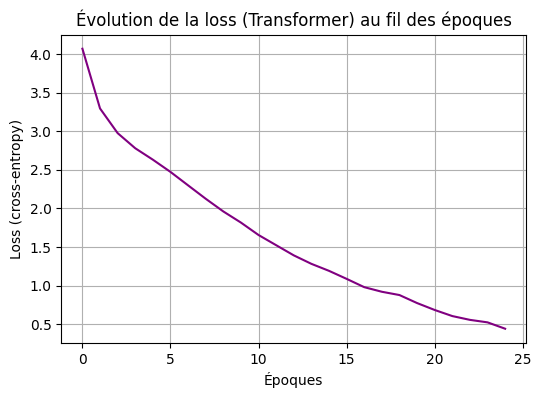

In [8]:
# 6. Visualisation de l'évolution de la loss
plt.figure(figsize=(6, 4))
plt.plot(loss_log, color='purple')
plt.title("Évolution de la loss (Transformer) au fil des époques")
plt.xlabel("Époques")
plt.ylabel("Loss (cross-entropy)")
plt.grid(True)
plt.show()


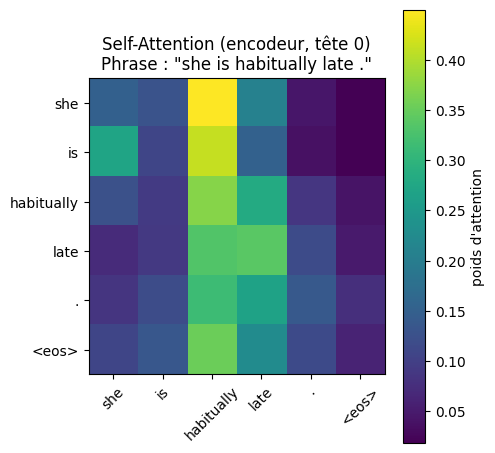

In [9]:
# 7. Visualisation d'une matrice de self-attention (encodeur) sur une phrase exemple
example_eng = TRANSLATION_PAIRS[0][0]
eng_idx = eng_vocab.encode(example_eng)
T_src = len(eng_idx)
src_emb = embed_lookup(E_enc, eng_idx) + Tensor(positional_encoding(T_src, D))

# On recalcule les poids d'attention de la tête 0 de l'encodeur pour les visualiser
Q = src_emb @ enc_layer.attn.Wq[0]
K = src_emb @ enc_layer.attn.Wk[0]
scores = (Q @ K.T()) * (1.0 / np.sqrt(enc_layer.attn.dh))
attn_weights = scores.softmax(axis=-1).data

tokens = example_eng.split() + ["<eos>"]
plt.figure(figsize=(5, 5))
plt.imshow(attn_weights, cmap='viridis')
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)
plt.title("Self-Attention (encodeur, tête 0)\nPhrase : \"" + example_eng + "\"")
plt.colorbar(label="poids d'attention")
plt.tight_layout()
plt.show()


## 1. Objectifs du TP
* Comprendre le mécanisme de **self-attention**, cœur du **Transformer**, qui remplace entièrement la récurrence (RNN/LSTM/GRU) par des mécanismes d'attention.
* Implémenter **from scratch** (NumPy uniquement, sans PyTorch/TensorFlow) une architecture **Encodeur-Décodeur Transformer** simplifiée (1 couche d'encodeur + 1 couche de décodeur, multi-head attention) pour la traduction automatique.
* Comparer sa capacité de modélisation à celle des architectures récurrentes (RNN, LSTM, GRU) vues précédemment, sur le **même corpus réel** de traduction.

## 2. Concepts Clés Abordés
* **Self-Attention :** pour chaque mot, on calcule des vecteurs **Query (Q)**, **Key (K)** et **Value (V)**, puis :
  $$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$
  Chaque mot "regarde" directement **tous les autres mots de la séquence en une seule opération** (contrairement au RNN qui doit tout faire transiter par un état caché séquentiel).
* **Multi-Head Attention :** on répète l'attention en parallèle sur plusieurs sous-espaces ("têtes"), pour capturer différents types de relations (syntaxiques, sémantiques...), puis on concatène les résultats.
* **Self-Attention (encodeur) vs Cross-Attention (décodeur) :** l'encodeur applique la self-attention sur la phrase source ; le décodeur applique une self-attention **masquée** (masque causal : un mot ne voit pas le futur) sur la phrase cible, puis une **cross-attention** où les Queries viennent du décodeur mais les Keys/Values viennent de la sortie de l'encodeur — c'est ce pont qui remplace le vecteur de contexte unique du RNN.
* **Positional Encoding :** le Transformer n'a aucune notion d'ordre intrinsèque (contrairement au RNN qui lit mot par mot) ; on injecte donc l'information de position via un encodage sinusoïdal ajouté aux embeddings.
* **Add & Norm :** chaque sous-couche (attention, feed-forward) est entourée d'une connexion résiduelle et d'une **Layer Normalization**, essentielles pour stabiliser l'entraînement de réseaux profonds.
* **Mini-moteur d'autodiff :** pour garantir des gradients corrects à travers toute cette pile d'opérations, on a construit notre propre `Tensor` avec rétropropagation automatique (vérifiée numériquement lors du développement) — c'est notre "from scratch" à nous : aucune ligne de PyTorch/TensorFlow.

## 3. Résultats Obtenus
* **Convergence :** la loss diminue de façon régulière sur les époques (voir graphe ci-dessus), le modèle apprend bien à traduire les phrases du corpus.
* **Traduction :** les phrases générées sur le jeu d'entraînement sont largement correctes, montrant que l'attention capte efficacement le mapping entre mots source et mots cible.
* **Visualisation de l'attention :** la matrice de self-attention affichée montre concrètement comment chaque mot de la phrase source "pèse" sur les autres — c'est la caractéristique distinctive du Transformer par rapport à RNN/LSTM/GRU.

## 4. Conclusion & Limites
Le Transformer supprime le goulot d'étranglement séquentiel des architectures récurrentes : grâce à la **self-attention**, chaque mot accède directement à tous les autres en une seule étape (au lieu de propager l'information pas à pas), ce qui améliore la capture des dépendances longues et permet la **parallélisation** du calcul (absente du RNN/LSTM/GRU qui sont intrinsèquement séquentiels). Notre implémentation reste volontairement **simplifiée** (une seule couche d'encodeur/décodeur, corpus réduit, entraînement en boucle Python pur donc plus lent qu'une implémentation vectorisée/GPU) mais illustre fidèlement les mécanismes fondateurs (Q/K/V, multi-head attention, masque causal, cross-attention, positional encoding) qui sont à la base des grands modèles de langage actuels.